# **Importing all the necessary libraries**

In [ ]:
# ==========================================================
# IMPORTING ALL REQUIRED LIBRARIES
# Fraud Detection Machine Learning Project
# ==========================================================

# -------------------------------
# Data Manipulation Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler,LabelEncoder)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,log_loss,roc_auc_score,roc_curve,precision_score,recall_score,f1_score)

# -------------------------------
# Ignore Warnings
# -------------------------------

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load CSV dataset
case_data = pd.read_csv("/content/case_data.csv")

# Load Excel dataset
personal_data = pd.read_excel("/content/personal_data.xlsx")

# **Check Dataset Information**

In [ ]:
print("Case Dataset Shape:")
print(case_data.shape)


print("\nPersonal Dataset Shape:")
print(personal_data.shape)

Case Dataset Shape:
(5000, 10)

Personal Dataset Shape:
(5000, 6)


# **Merge Both Datasets Using ID Only**

In [ ]:
# Merge datasets using only ID column

fraud_data = pd.merge(case_data,personal_data,on="ID",how="inner")

In [ ]:
fraud_data.head()

,ID,transaction_amount,account_tenure_years,num_prior_fraud_flags,country_risk_score,is_international,merchant_category,hour_of_day,channel,is_fraud,customer_age,device_trust_score,ethnicity,gender,country_of_origin
0,10367,239.367939,1.961895,0,2,0,clothing,9,web,0,70,0.788579,Other,Male,Nigeria
1,10368,149.446473,8.014908,0,6,0,electronics,18,mobile,0,46,0.711116,Other,Male,France
2,10369,138.228358,1.182699,0,9,1,travel,20,branch,1,40,0.319214,Black,Female,France
3,10370,138.230229,3.943605,0,4,0,grocery,10,mobile,0,74,0.490208,Asian,Male,UK
4,10371,464.971441,0.991329,0,3,0,clothing,11,web,1,67,0.076153,Asian,Female,India


In [ ]:
fraud_data.to_csv("combined_fraud_dataset.csv",index=False)

# **Handing Missing and Duplicate Records**

In [ ]:
fraud_data.isnull().sum()

,0
ID,0
transaction_amount,0
account_tenure_years,0
num_prior_fraud_flags,0
country_risk_score,0
is_international,0
merchant_category,0
hour_of_day,0
channel,0
is_fraud,0


In [ ]:
fraud_data.duplicated().sum()

np.int64(0)

# **Outlier Plot 1: Transaction Amount Boxplot**

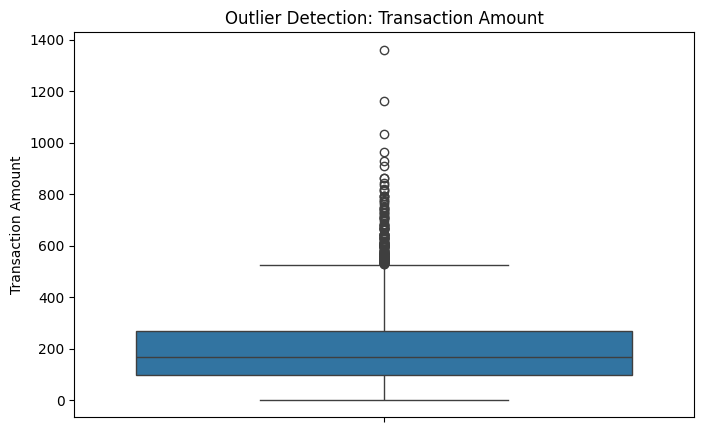

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=fraud_data,y='transaction_amount')
plt.title("Outlier Detection: Transaction Amount")
plt.ylabel("Transaction Amount")
plt.show()

# **Outlier Plot 2: Customer Age Boxplot**

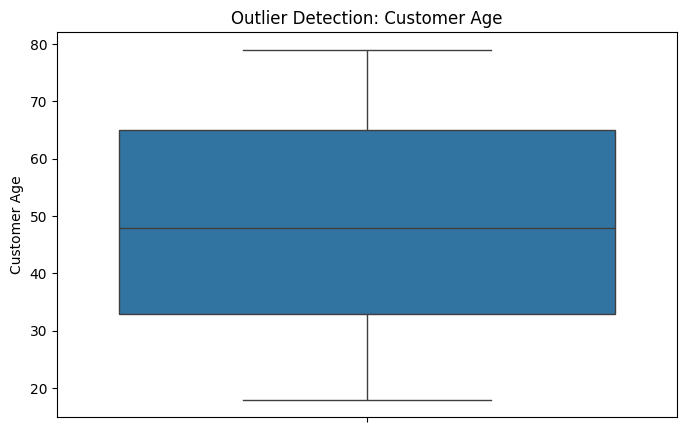

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=fraud_data,y='customer_age')
plt.title("Outlier Detection: Customer Age")

plt.ylabel("Customer Age")
plt.show()

# **Descriptive Analysis**

## **Average Transaction Amount Calculation**

In [ ]:
# Calculate average transaction amount
average_transaction_amount = fraud_data['transaction_amount'].mean()
print("Average Transaction Amount: £",round(average_transaction_amount,2))

Average Transaction Amount: £ 201.75


## **Median Transaction Amount Calculation**

In [ ]:
# Calculate median transaction amount
median_transaction_amount = fraud_data['transaction_amount'].median()

print("Median Transaction Amount: £",round(median_transaction_amount,2))

Median Transaction Amount: £ 169.13


## **Average Customer Age Calculation**

In [ ]:
# Calculate average customer age

average_customer_age = fraud_data['customer_age'].mean()
print("Average Customer Age:",round(average_customer_age,2),"years")

Average Customer Age: 48.52 years


## **Average Account Tenure Calculation**

In [ ]:
# Calculate average account tenure

average_account_tenure = fraud_data['account_tenure_years'].mean()
print("Average Account Tenure:",round(average_account_tenure,2),"years")

Average Account Tenure: 5.08 years


## **Distribution of Merchant Category**

In [ ]:
# Replace abbreviations with full labels
fraud_data['merchant_category'] = fraud_data['merchant_category'].replace({
    'l': 'luxury',
    'c': 'clothing',
    'e': 'electronics',
    't': 'travel'
})

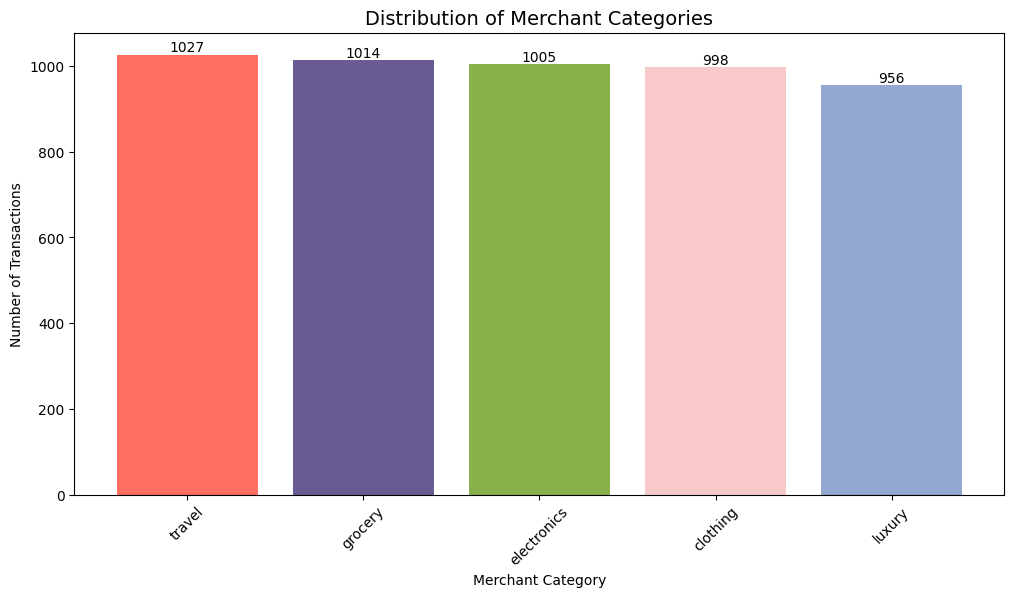

In [ ]:
# Count merchant categories

merchant_counts = (
    fraud_data['merchant_category']
    .value_counts()
)
# Create graph
plt.figure(figsize=(12,6))
bars = plt.bar(
    merchant_counts.index,
    merchant_counts.values,
    color=[
        '#FF6F61',
        '#6B5B95',
        '#88B04B',
        '#F7CAC9',
        '#92A8D1'
    ]
)
# Add labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )
plt.title(
    "Distribution of Merchant Categories",
    fontsize=14
)
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

## **Distribution of Ethnicity**

In [ ]:
# Replace abbreviations with full labels
fraud_data['ethnicity'] = fraud_data['ethnicity'].replace({
    'A': 'Asian',
    'W': 'White'
})

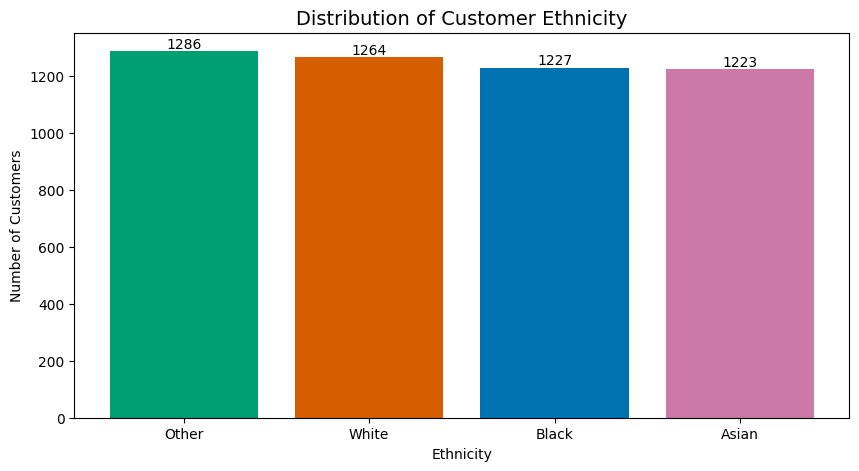

In [ ]:
# Count ethnicity categories

ethnicity_counts = (
    fraud_data['ethnicity']
    .value_counts()
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    ethnicity_counts.index,
    ethnicity_counts.values,
    color=[
        '#009E73',
        '#D55E00',
        '#0072B2',
        '#CC79A7'
    ]
)
# Add data labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )
plt.title(
    "Distribution of Customer Ethnicity",
    fontsize=14
)
plt.xlabel("Ethnicity")
plt.ylabel("Number of Customers")
plt.show()

## **Distribution of Transaction Amount**

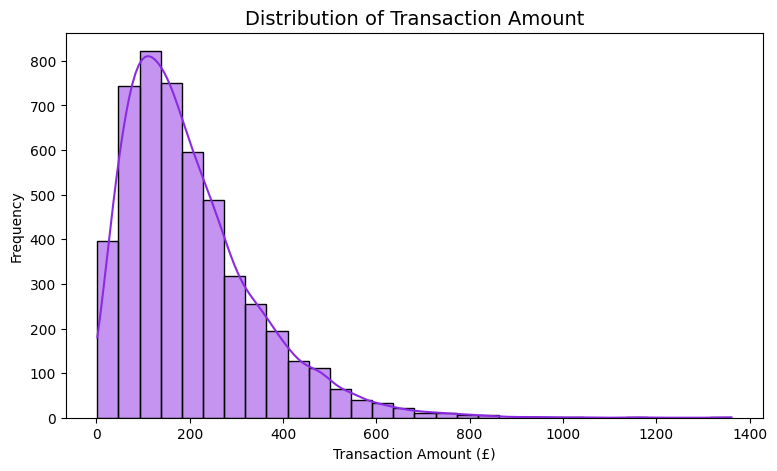

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(
    fraud_data['transaction_amount'],
    bins=30,
    kde=True,
    color='#8A2BE2'
)
plt.title(
    "Distribution of Transaction Amount",
    fontsize=14
)
plt.xlabel(
    "Transaction Amount (£)"
)
plt.ylabel(
    "Frequency"
)
plt.show()

## **Distribution of Hour of Day**

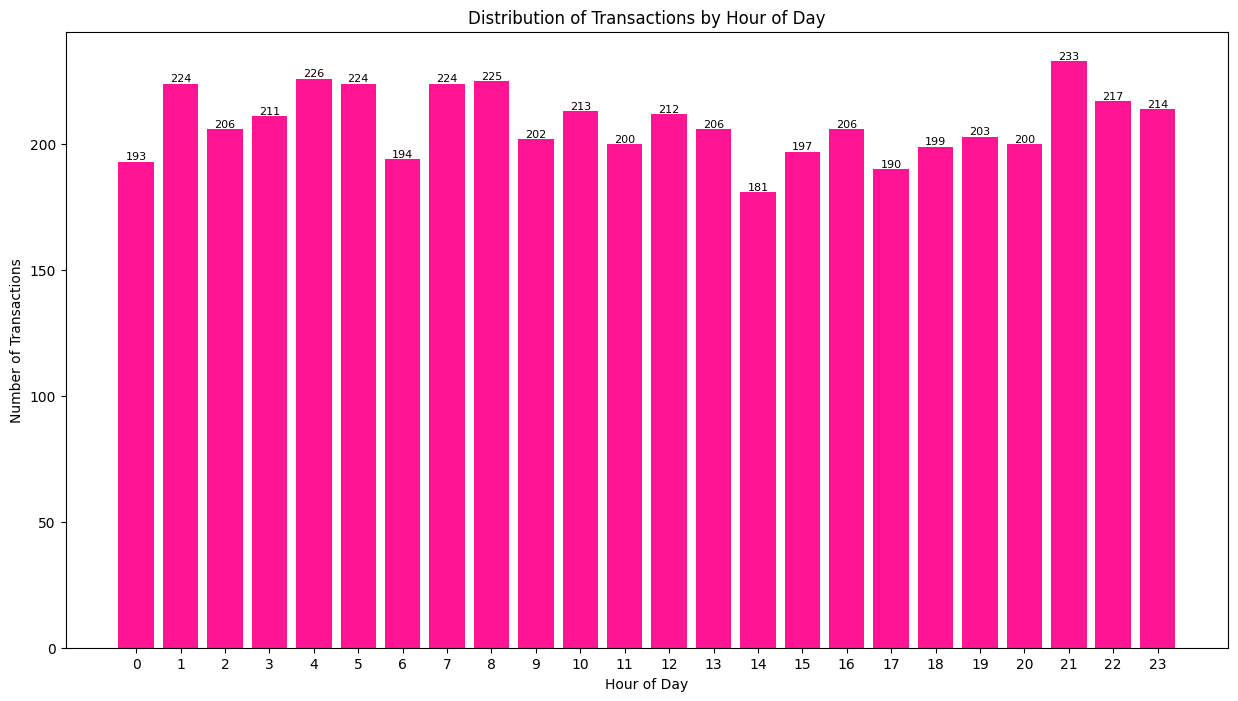

In [ ]:
hour_distribution = (
    fraud_data['hour_of_day']
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(15,8))
bars = plt.bar(
    hour_distribution.index,
    hour_distribution.values,
    color='#FF1493'
)
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )
plt.title(
    "Distribution of Transactions by Hour of Day"
)
plt.xlabel(
    "Hour of Day"
)
plt.ylabel(
    "Number of Transactions"
)
plt.xticks(
    range(0,24)
)
plt.show()

## **Correlation Between Transaction Amount and Fraud**

In [ ]:
transaction_fraud_corr = (
    fraud_data[
        ['transaction_amount','is_fraud']
    ]
    .corr()
)
transaction_fraud_corr

,transaction_amount,is_fraud
transaction_amount,1.000000,0.040346
is_fraud,0.040346,1.000000


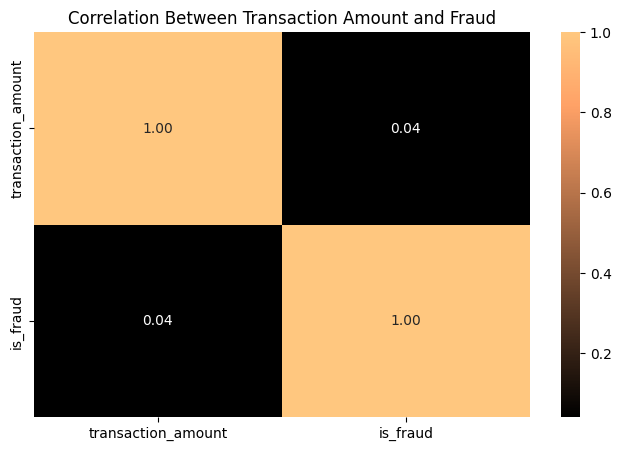

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    transaction_fraud_corr,
    annot=True,
    cmap='copper',
    fmt=".2f"
)
plt.title("Correlation Between Transaction Amount and Fraud")
plt.show()

## **Correlation Between Previous Fraud Flags and Fraud**

In [ ]:
fraud_data['num_prior_fraud_flags'] = pd.to_numeric(fraud_data['num_prior_fraud_flags'], errors='coerce')
fraud_data['num_prior_fraud_flags'] = fraud_data['num_prior_fraud_flags'].fillna(0)

prior_fraud_corr = (
    fraud_data[
        [
            'num_prior_fraud_flags',
            'is_fraud'
        ]
    ]
    .corr()
)
prior_fraud_corr

,num_prior_fraud_flags,is_fraud
num_prior_fraud_flags,1.000000,0.216636
is_fraud,0.216636,1.000000


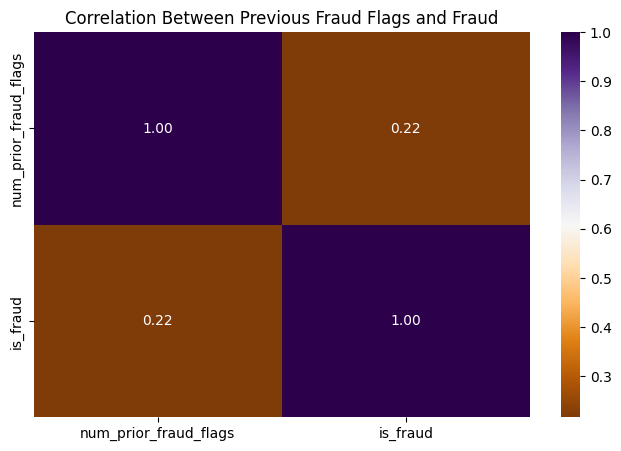

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    prior_fraud_corr,
    annot=True,
    cmap='PuOr',
    fmt=".2f"
)
plt.title(
    "Correlation Between Previous Fraud Flags and Fraud"
)
plt.show()

# **Data Preparation**

In [ ]:
# Remove ID column
model_data = fraud_data.drop(
    columns=['ID']
)
model_data.head()

,transaction_amount,account_tenure_years,num_prior_fraud_flags,country_risk_score,is_international,merchant_category,hour_of_day,channel,is_fraud,customer_age,device_trust_score,ethnicity,gender,country_of_origin
0,239.367939,1.961895,0.0,2,0,clothing,9,web,0,70,0.788579,Other,Male,Nigeria
1,149.446473,8.014908,0.0,6,0,electronics,18,mobile,0,46,0.711116,Other,Male,France
2,138.228358,1.182699,0.0,9,1,travel,20,branch,1,40,0.319214,Black,Female,France
3,138.230229,3.943605,0.0,4,0,grocery,10,mobile,0,74,0.490208,Asian,Male,UK
4,464.971441,0.991329,0.0,3,0,clothing,11,web,1,67,0.076153,Asian,Female,India


## **Features and Target Variable**

In [ ]:
# Independent variables

X = model_data.drop(
    'is_fraud',
    axis=1
)


# Dependent variable

y = model_data['is_fraud']

## **Identify Categorical and Numerical Columns**

In [ ]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns
numerical_columns = X.select_dtypes(
    include=['int64','float64']
).columns

## **Encode Categorical Variables**

In [ ]:
# One hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

## **Train-test Splitting**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## **Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)

# **MODEL 1: DECISION TREE CLASSIFIER**

In [ ]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)
decision_tree.fit(
    X_train_scaled,
    y_train
)

DecisionTreeClassifier(max_depth=8, random_state=42)

In [ ]:
dt_prediction = decision_tree.predict(
    X_test_scaled
)
dt_probability = decision_tree.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)


print(
    "Decision Tree Accuracy:",
    round(dt_accuracy,4)
)

Decision Tree Accuracy: 0.64


In [ ]:
print(
    classification_report(
        y_test,
        dt_prediction
    )
)

              precision    recall  f1-score   support

           0       0.62      0.64      0.63       476
           1       0.66      0.64      0.65       524

    accuracy                           0.64      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.64      0.64      0.64      1000



In [ ]:
dt_logloss = log_loss(
    y_test,
    decision_tree.predict_proba(X_test_scaled)
)


print(
    "Decision Tree Log Loss:",
    round(dt_logloss,4)
)

Decision Tree Log Loss: 1.6506


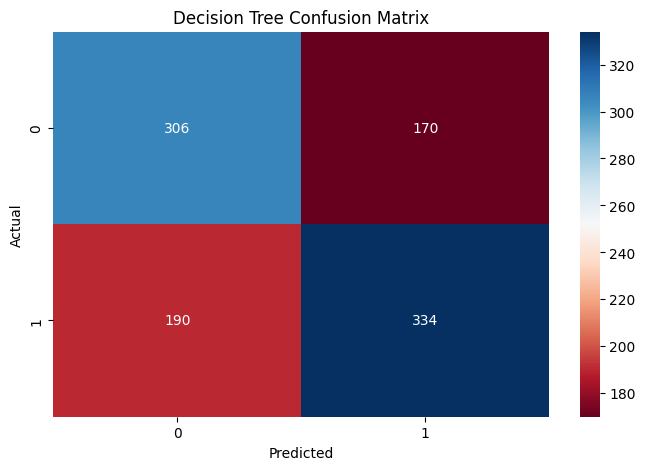

In [ ]:
dt_cm = confusion_matrix(
    y_test,
    dt_prediction
)
plt.figure(figsize=(8,5))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='RdBu'
)
plt.title(
    "Decision Tree Confusion Matrix"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.show()

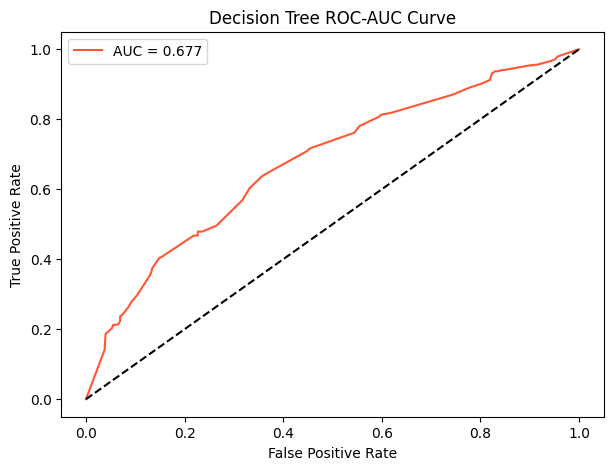

In [ ]:
dt_auc = roc_auc_score(
    y_test,
    dt_probability
)


fpr, tpr, threshold = roc_curve(
    y_test,
    dt_probability
)



plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {dt_auc:.3f}",
    color='#FF5733'
)


plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)


plt.title(
    "Decision Tree ROC-AUC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()

plt.show()

# **MODEL 2: ADABOOST CLASSIFIER**

In [ ]:
adaboost_model = AdaBoostClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.5
)
adaboost_model.fit(
    X_train_scaled,
    y_train
)

AdaBoostClassifier(learning_rate=0.5, n_estimators=100, random_state=42)

In [ ]:
ada_prediction = adaboost_model.predict(
    X_test_scaled
)
ada_probability = adaboost_model.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
ada_accuracy = accuracy_score(
    y_test,
    ada_prediction
)


print(
    "AdaBoost Accuracy:",
    round(ada_accuracy,4)
)

AdaBoost Accuracy: 0.67


In [ ]:
print(
    classification_report(
        y_test,
        ada_prediction
    )
)

              precision    recall  f1-score   support

           0       0.66      0.62      0.64       476
           1       0.67      0.72      0.69       524

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000



In [ ]:
ada_logloss = log_loss(
    y_test,
    adaboost_model.predict_proba(
        X_test_scaled
    )
)


print(
    "AdaBoost Log Loss:",
    round(ada_logloss,4)
)

AdaBoost Log Loss: 0.6266


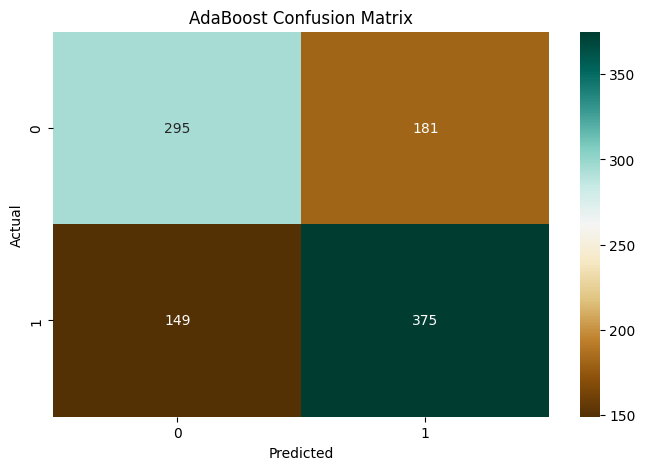

In [ ]:
ada_cm = confusion_matrix(
    y_test,
    ada_prediction
)
plt.figure(figsize=(8,5))


sns.heatmap(
    ada_cm,
    annot=True,
    fmt='d',
    cmap='BrBG'
)


plt.title(
    "AdaBoost Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

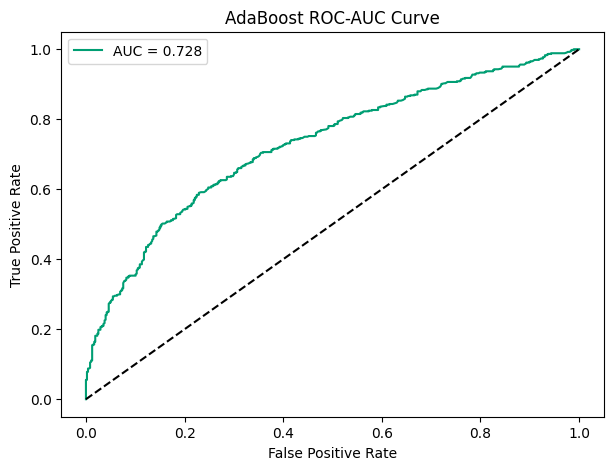

In [ ]:
ada_auc = roc_auc_score(
    y_test,
    ada_probability
)


fpr, tpr, threshold = roc_curve(
    y_test,
    ada_probability
)



plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {ada_auc:.3f}",
    color='#009E73'
)


plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)



plt.title(
    "AdaBoost ROC-AUC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()


plt.show()

In [ ]:
model_comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "AdaBoost"
    ],

    "Accuracy":[
        dt_accuracy,
        ada_accuracy
    ],

    "Log Loss":[
        dt_logloss,
        ada_logloss
    ],

    "ROC-AUC":[
        dt_auc,
        ada_auc
    ]

})


model_comparison

,Model,Accuracy,Log Loss,ROC-AUC
0,Decision Tree,0.64,1.650650,0.676705
1,AdaBoost,0.67,0.626565,0.727919


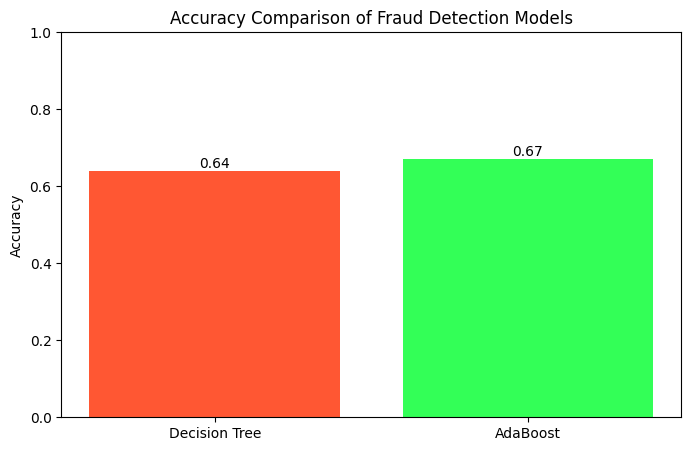

In [ ]:
plt.figure(figsize=(8,5))


bars = plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy'],
    color=[
        '#FF5733',
        '#33FF57'
    ]
)


for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),3),
        ha='center',
        va='bottom'
    )


plt.title(
    "Accuracy Comparison of Fraud Detection Models"
)


plt.ylabel(
    "Accuracy"
)


plt.ylim(
    0,
    1
)


plt.show()